<a href="https://colab.research.google.com/github/Alvaro217-h/Challenge_Telecom_X/blob/main/challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Estracion de datos**
url API = https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json

In [ ]:
url_json = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [ ]:
import requests
import pandas as pd

In [ ]:
response = requests.get(url_json)
data = response.json()
datos_telcom = pd.DataFrame(data)
datos_telcom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##**Normalizando archivos json**

In [ ]:
datos_telcom = pd.json_normalize(data)
datos_telcom

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
datos_telcom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#**Transformación (T - Transform)**

## **Valores nulos**

In [ ]:
datos_telcom.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


##**Valores vacios**

In [ ]:
datos_telcom.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


###Elimiar filas vacias en Churn

In [ ]:
datos_telcom= datos_telcom[datos_telcom['Churn'].str.strip() != '']

###Eliminar filas vacias en account.Charges.Total

In [ ]:
datos_telcom['account.Charges.Total'] = pd.to_numeric(datos_telcom['account.Charges.Total'], errors='coerce')

/tmp/ipython-input-46988379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_telcom['account.Charges.Total'] = pd.to_numeric(datos_telcom['account.Charges.Total'], errors='coerce')


###Verificar Vacios

In [ ]:
datos_telcom.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#**Carga y análisis(L - Load & Analysis)**

##Distribución de evasión

In [ ]:
datos_telcom.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
datos_telcom['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


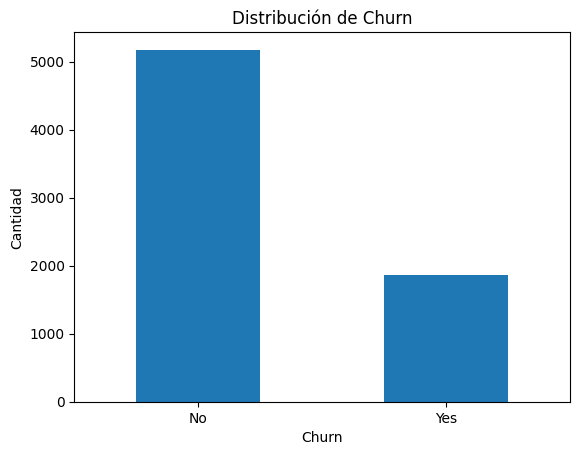

In [ ]:
datos_telcom['Churn'].value_counts().plot(kind='bar')

plt.title('Distribución de Churn')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

##Recuento de evasión por variables categóricas

###Genero

In [ ]:
pd.crosstab(datos_telcom['customer.gender'], datos_telcom['Churn'])

Churn,No,Yes
customer.gender,,
Female,2549,939
Male,2625,930


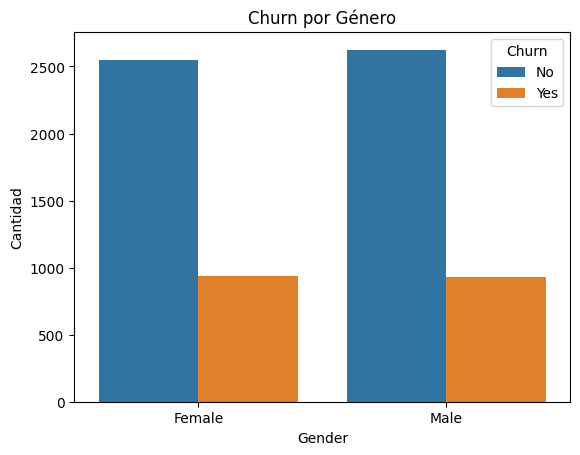

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=datos_telcom, x='customer.gender', hue='Churn')

plt.title('Churn por Género')
plt.ylabel('Cantidad')
plt.xlabel('Gender')
plt.show()

###Tipo de contrato

In [ ]:
pd.crosstab(datos_telcom['account.Contract'], datos_telcom['Churn'])

Churn,No,Yes
account.Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


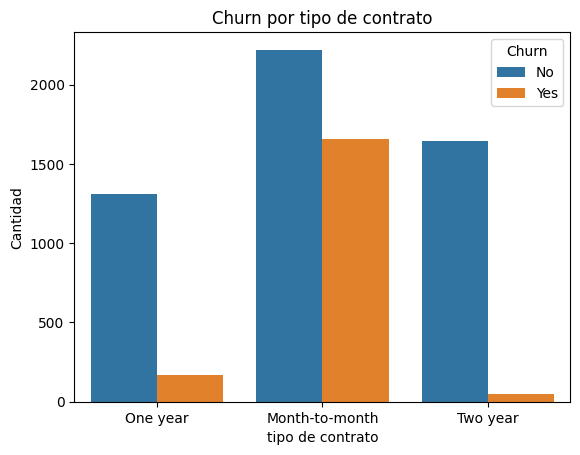

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=datos_telcom, x='account.Contract', hue='Churn')

plt.title('Churn por tipo de contrato')
plt.ylabel('Cantidad')
plt.xlabel('tipo de contrato')
plt.show()

###Método de pago

In [ ]:
pd.crosstab(datos_telcom['account.PaymentMethod'], datos_telcom['Churn'])

Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


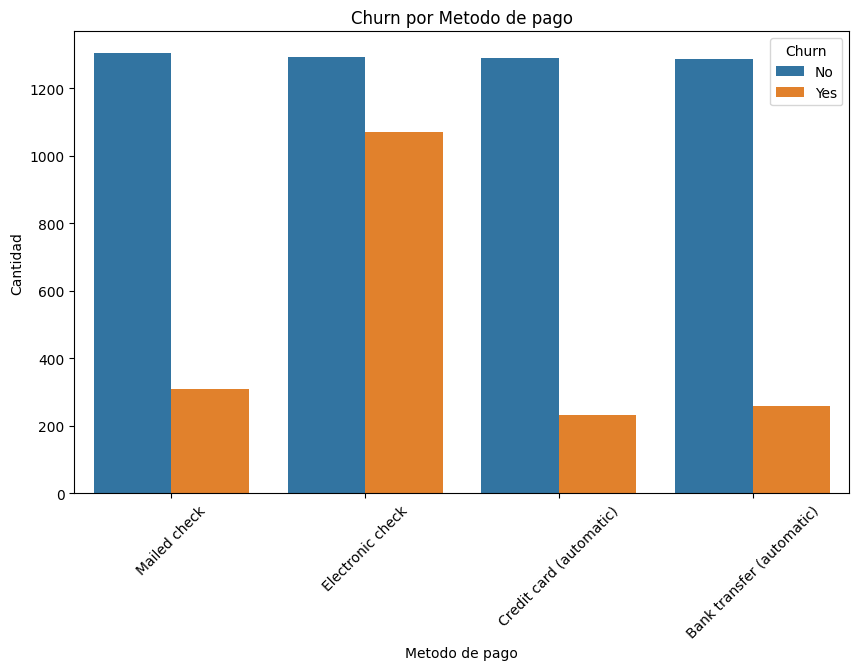

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))  # ancho, alto en pulgadas

sns.countplot(data=datos_telcom, x='account.PaymentMethod', hue='Churn')

plt.title('Churn por Metodo de pago')
plt.ylabel('Cantidad')
plt.xlabel('Metodo de pago')
plt.xticks(rotation=45)  # opcional si los nombres son largos
plt.show()

#Informe


# **Telecom X - Análisis de Evasión de Clientes (Churn)**

## **Introducción**

Telecom X enfrenta una alta tasa de cancelación de clientes (Churn), lo que impacta directamente en los ingresos y la estabilidad del negocio.

El objetivo de este análisis fue identificar los principales factores asociados a la evasión de clientes utilizando Python y herramientas como Pandas, Matplotlib y Seaborn.

La tasa general de churn encontrada en el dataset fue:

***ChurnRate = 26.5***

Esto significa que aproximadamente 1 de cada 4 clientes cancela el servicio, lo cual representa un nivel preocupante para la compañía.


---


## **Limpieza y Tratamiento de Datos**

Durante la preparación de los datos se realizaron los siguientes pasos:


*   Importación de datos con Pandas.
*   Verificación de valores nulos (isnull().sum()).
*   Revisión de espacios en blanco en variables categóricas
*   Eliminación de filas vacías.
*   Conversión de columnas numéricas al tipo float cuando fue necesario.
*   Agrupación de variables categóricas para análisis de frecuencia (gender, contract, payment method).

Estos pasos garantizaron que el dataset estuviera limpio y listo para el análisis exploratorio.



---


## **Análisis Exploratorio de Datos (EDA)**

###**-Churn por Género**

Se encontró que la diferencia de churn entre hombres y mujeres es mínima.

Las mujeres presentan una tasa ligeramente mayor, pero la diferencia no es estadísticamente significativa y no se considera un factor determinante.

*Conclusión:*

El género no es una variable relevante para explicar la evasión.

###**-Churn por Tipo de Contrato**
Se analizaron tres tipos de contrato:

* Month-to-month

* One year

* Two year

El contrato con mayor churn fue:

* ***Month-to-month = 1665 clientes***

Los contratos mensuales presentan una tasa de cancelación significativamente mayor en comparación con contratos de uno o dos años.

*Conclusión:*

Los clientes sin compromiso a largo plazo tienen mayor probabilidad de abandonar el servicio.

###**-Churn por Método de Pago**

Se analizaron cuatro métodos de pago:

* Bank Transfer

* Credit Card

* Electronic Check

* Mailed Check

El método con mayor churn fue:

* ***Electronic Check = 1071clientes***

Los clientes que pagan mediante Electronic Check presentan mayor evasión.

*Posible explicación:*

Este método puede estar asociado a clientes con menor fidelización o mayor sensibilidad al precio.


---


##**Conclusiones e Insights**

Del análisis se identificaron los siguientes hallazgos clave:

* La tasa general de churn es alta (26.5%).

* El género no influye significativamente en la cancelación.

* El contrato month-to-month es el principal factor asociado al churn.

* El método de pago Electronic Check está relacionado con mayor evasión.

El factor más determinante identificado fue el tipo de contrato.

---



##**Recomendaciones Estratégicas**

Basado en el análisis, se sugieren las siguientes acciones:

1. Incentivar contratos a largo plazo

    *  Ofrecer descuentos o beneficios adicionales para contratos de 1 o 2 años.

    * Crear campañas de fidelización para clientes month-to-month.

2. Revisar clientes con Electronic Check

    * Analizar el perfil de estos clientes.

    * Ofrecer incentivos para migrar a pago automático con tarjeta o transferencia bancaria.

3. Estrategias de retención temprana

    * Identificar clientes nuevos con contrato mensual.

    * Aplicar campañas de seguimiento en los primeros meses.
